In [1]:
%load_ext autoreload
%autoreload 2

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

In [3]:
cash = 1_000_000

In [4]:
from priceloader import PriceLoader

# Load the data
data_dir = "../data/"
    
loader = PriceLoader("2005-01-01", "2025-01-01", data_dir)
tickers = loader.fetch_sp500_tickers()
if os.path.isdir(data_dir):
    if not os.listdir(data_dir):
        print("Batch downloading data")
        loader.batch_download(tickers=tickers)
    else:
        print("Data already downloaded")
else:
    print("Data already downloaded")

/Users/cmbenello/Coding/uchicago/grad/finm-325/hw2/src/priceloader.py:28: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Batch downloading data


[*********************100%***********************]  100 of 100 completed
[*********************100%***********************]  100 of 100 completed
[*********************100%***********************]  100 of 100 completed
[*********************100%***********************]  100 of 100 completed
[*********************100%***********************]  100 of 100 completed
[*********************100%***********************]  3 of 3 completed


In [ ]:
_ = loader.read_ticker("aapl")
prices = loader.batch_read_close()
volumes = loader.batch_read_volume() 

xtx
                 TGT     CBRE      MCO       CI       HAL      EMN      GPN  \
Date                                                                          
2005-01-03   4434100  1862400  1329600  2595600   9752000  1915200  1226400   
2005-01-04   2424500  1307400  1072600  4178100   8532800  9916200  1287200   
2005-01-05   2580900  2315100   983000  3882300  11291200  4925200  1202000   
2005-01-06  13875000  1278300  1021400  4538700  10787600  3350200  1575600   
2005-01-07   6716600   902400   669600  3200100   7503600  1722200  1587600   

                DGX      BSX  IQV  ...       CL      AXP     TKO     BKNG  \
Date                               ...                                      
2005-01-03   794200  6101000  NaN  ...  5383200  5251571   86000  1110000   
2005-01-04  1031800  3242800  NaN  ...  3895800  4642294   89500  2960700   
2005-01-05  1408000  4029800  NaN  ...  8916000  4681481  176400   883300   
2005-01-06  1601200  3669200  NaN  ...  5987200  4947675 

In [16]:
from strategies import (
    Benchmark_Strategy,
    MACDStrategy,
    MovingAverageStrategy,
    RSIStrategy,
    VolatilityBreakoutStrategy,
)

bench = Benchmark_Strategy(
    initial_cash=1_000_000.0, 
    participation_rate=0.10,
    adv_window=20,            
    dollar_cap_usd=None        
)

bench_signals = bench.generate_signals(
    close_df=prices,
    vol_df=volumes,
)

#Generate signals
mas = MovingAverageStrategy(20, 50)
mas_signals = mas.generate_signals(prices)

vbs = VolatilityBreakoutStrategy(20)
vbs_signals = vbs.generate_signals(prices)

macd = MACDStrategy(12, 26, 9) # I think default strategies
macd_signals = macd.generate_signals(prices)

rsi = RSIStrategy(14, 30) # Same for this
rsi_signals = rsi.generate_signals(prices)

/Users/cmbenello/Coding/uchicago/grad/finm-325/hw2/src/strategies/MovingAverageStrategy.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  signal_t1 = cross_up.shift(1).fillna(False).astype("Int8")
/Users/cmbenello/Coding/uchicago/grad/finm-325/hw2/src/strategies/VolatilityBreakoutStrategy.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  signal = (daily_returns > vol_window).shift(1).fillna(False).astype("Int8")
/Users/cmbenello/Coding/uchicago/grad/finm-325/hw2/src/strategies/MACDStrategy.py:26: FutureWarning: Downcasting object dtype arrays on .f

In [26]:
from backtester import Backtester

bt = Backtester(prices, initial_cash=1_000_000.0)

strategies = {
    "Bench": bench_signals,
    "RSI": rsi_signals,
    "MACD": macd_signals,
    "MA": mas_signals,
    "VolBreak": vbs_signals,
}

results = {}
timings = {}

for name, sig in strategies.items():
    start = time.perf_counter()
    results[name] = bt.run(sig)
    end = time.perf_counter()
    timings[name] = end - start
    print(f"{name:10s} completed in {timings[name]:.3f} seconds")

# summary table
print("\n=== Backtest Timings ===")
for name, t in timings.items():
    print(f"{name:10s}: {t:.3f} s")
print(f"Total time: {sum(timings.values()):.3f} s")

Bench      completed in 0.129 seconds
RSI        completed in 0.491 seconds
MACD       completed in 0.387 seconds
MA         completed in 0.351 seconds
VolBreak   completed in 0.595 seconds

=== Backtest Timings ===
Bench     : 0.129 s
RSI       : 0.491 s
MACD      : 0.387 s
MA        : 0.351 s
VolBreak  : 0.595 s
Total time: 1.952 s


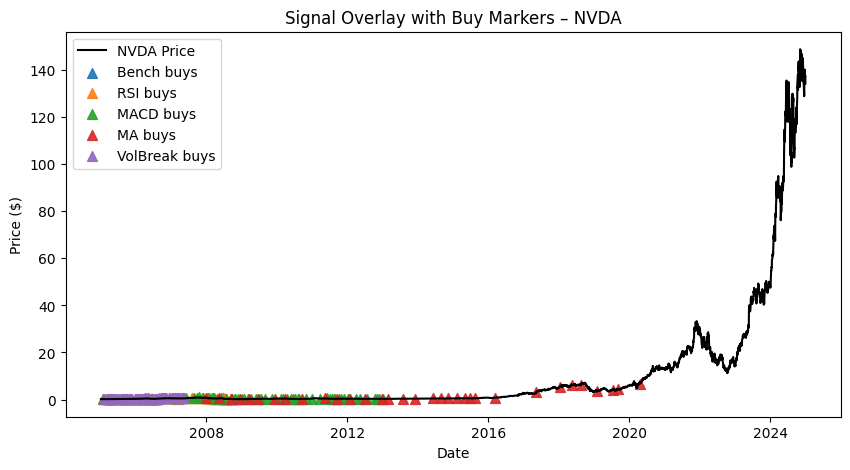

In [18]:
import matplotlib.pyplot as plt

ticker = "NVDA"
plt.figure(figsize=(10,5))

# price line
plt.plot(prices[ticker], label=f"{ticker} Price", color="black")

# overlay buy markers from each strategy's BacktestResult
for name, res in results.items():                   # results[name] -> BacktestResult
    eb = res.executed_buys                          # DataFrame (dates × tickers) with 0/1
    if ticker not in eb.columns:
        continue
    buy_dates = eb.index[eb[ticker] == 1]
    plt.scatter(
        buy_dates,
        prices.loc[buy_dates, ticker],
        label=f"{name} buys",
        marker="^",
        s=50,
        alpha=0.9,
    )

plt.title(f"Signal Overlay with Buy Markers – {ticker}")
plt.xlabel("Date"); plt.ylabel("Price ($)")
plt.legend(); plt.show()

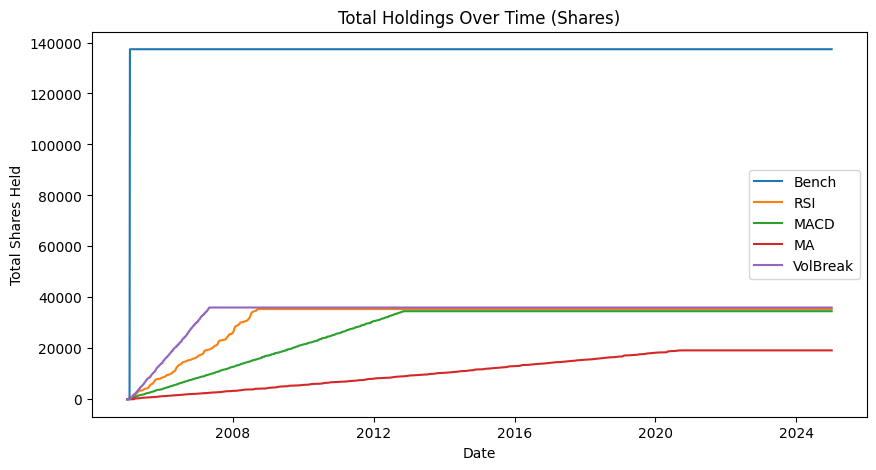

In [19]:
#Plot holdings
plt.figure(figsize=(10,5))

for name, res in results.items():
    total_holdings = res.shares.sum(axis=1)
    plt.plot(total_holdings.index, total_holdings.values, label=name)

plt.title("Total Holdings Over Time (Shares)")
plt.xlabel("Date")
plt.ylabel("Total Shares Held")
plt.legend()
plt.show()

                Bench        RSI            MACD         MA   VolBreak
Date                                                                  
2005-01-03  1000000.0  1000000.0  1000000.000000  1000000.0  1000000.0
2005-01-04  1000000.0  1000000.0  1000000.000000  1000000.0  1000000.0
2005-01-05  1000000.0  1000000.0   998554.173448  1000000.0  1000000.0
2005-01-06  1000000.0  1000000.0   998166.447598  1000000.0  1000000.0
2005-01-07  1000000.0  1000000.0   997438.331544  1000000.0  1000000.0


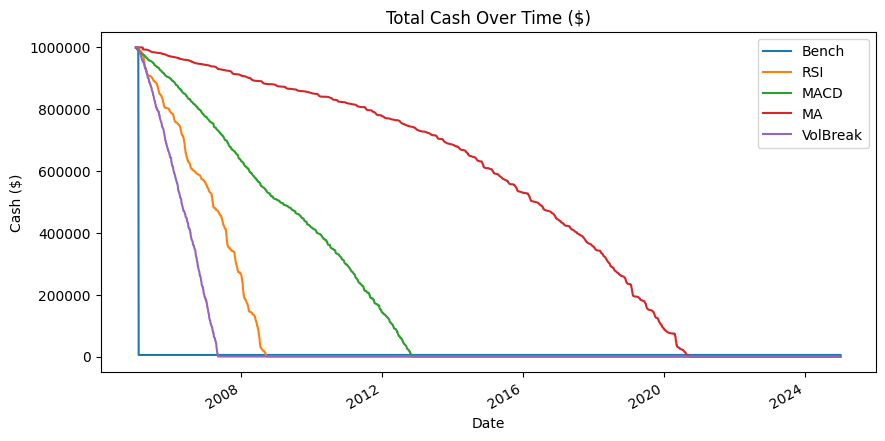

In [20]:
#Plot cash
cash_df = pd.DataFrame({name: res.cash.astype("float64") for name, res in results.items()})

print(cash_df.head())
ax = cash_df.plot(figsize=(10,5), title="Total Cash Over Time ($)")
ax.set_xlabel("Date")
ax.set_ylabel("Cash ($)")
ax.ticklabel_format(style="plain", axis="y")
plt.show()

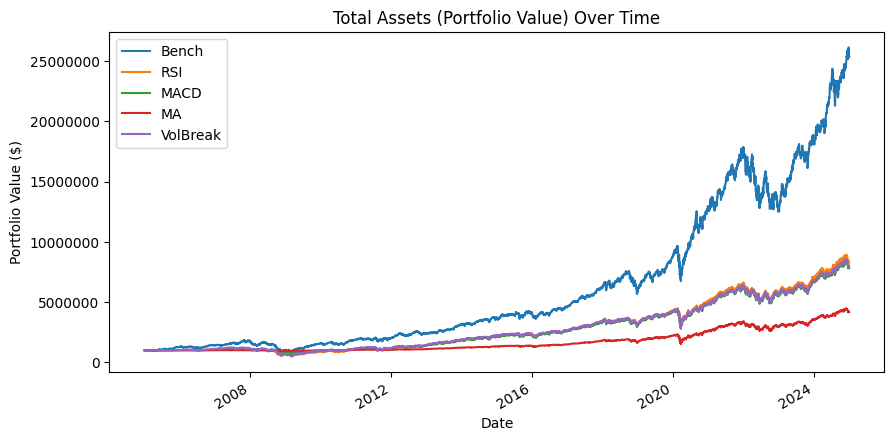

In [21]:

assets_df = pd.concat(
    {name: r.portfolio_value.astype("float64") for name, r in results.items()},
    axis=1
).sort_index().dropna(how="all")

ax = assets_df.plot(figsize=(10,5), title="Total Assets (Portfolio Value) Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Portfolio Value ($)")
ax.ticklabel_format(style="plain", axis="y")
plt.show()

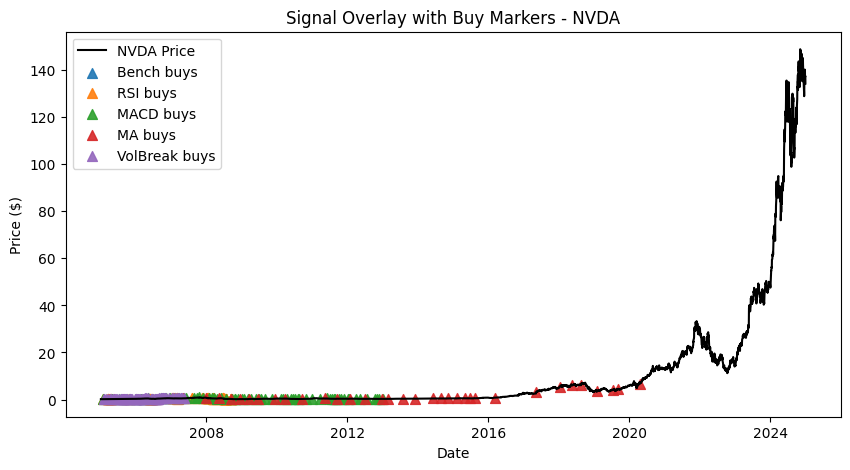

In [22]:
import matplotlib.pyplot as plt

ticker = "NVDA"
plt.figure(figsize=(10,5))

# price line
plt.plot(prices[ticker], label=f"{ticker} Price", color="black")

# overlay buy markers from each strategy's BacktestResult
for name, res in results.items():                   # results[name] -> BacktestResult
    eb = res.executed_buys                          # DataFrame (dates × tickers) with 0/1
    if ticker not in eb.columns:
        continue
    buy_dates = eb.index[eb[ticker] == 1]
    plt.scatter(
        buy_dates,
        prices.loc[buy_dates, ticker],
        label=f"{name} buys",
        marker="^",
        s=50,
        alpha=0.9,
    )

plt.title(f"Signal Overlay with Buy Markers - {ticker}")
plt.xlabel("Date"); plt.ylabel("Price ($)")
plt.legend(); plt.show()

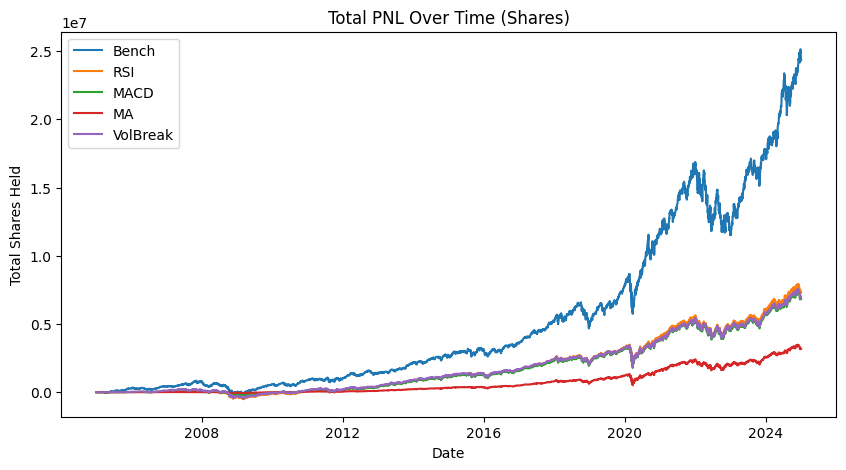

In [23]:
#Plot pnl
plt.figure(figsize=(10,5))

for name, res in results.items():
    pnl = res.pnl
    plt.plot(pnl.index, pnl.values, label=name)

plt.title("Total PNL Over Time (Shares)")
plt.xlabel("Date")
plt.ylabel("Total Shares Held")
plt.legend()
plt.show()